In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

In [ ]:
# Load dataset
file_path = "/loan_data.xlsx"
df = pd.read_excel(file_path, sheet_name='loan_data')

# Quick glance at the data
print(df.head())
print(df.info())

In [ ]:
# Exploratory Data Analysis (EDA) (1)

# Check for missing values
print("Check for missing values:")
print(df.isnull().sum())

# Basic statistics
print("Initial Exploratory Data Analysis:")
print(df.describe())

Check for missing values:
person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64
Initial Exploratory Data Analysis:
         person_age  person_income  person_emp_exp     loan_amnt  \
count  45000.000000   4.500000e+04    45000.000000  45000.000000   
mean      27.764178   8.031905e+04        5.410333   9583.157556   
std        6.045108   8.042250e+04        6.063532   6314.886691   
min       20.000000   8.000000e+03        0.000000    500.000000   
25%       24.000000   4.720400e+04        1.000000   5000.000000   
50%       26.0

EDA Visualisation through Histogram, Correlation Matrix & Count Plot:


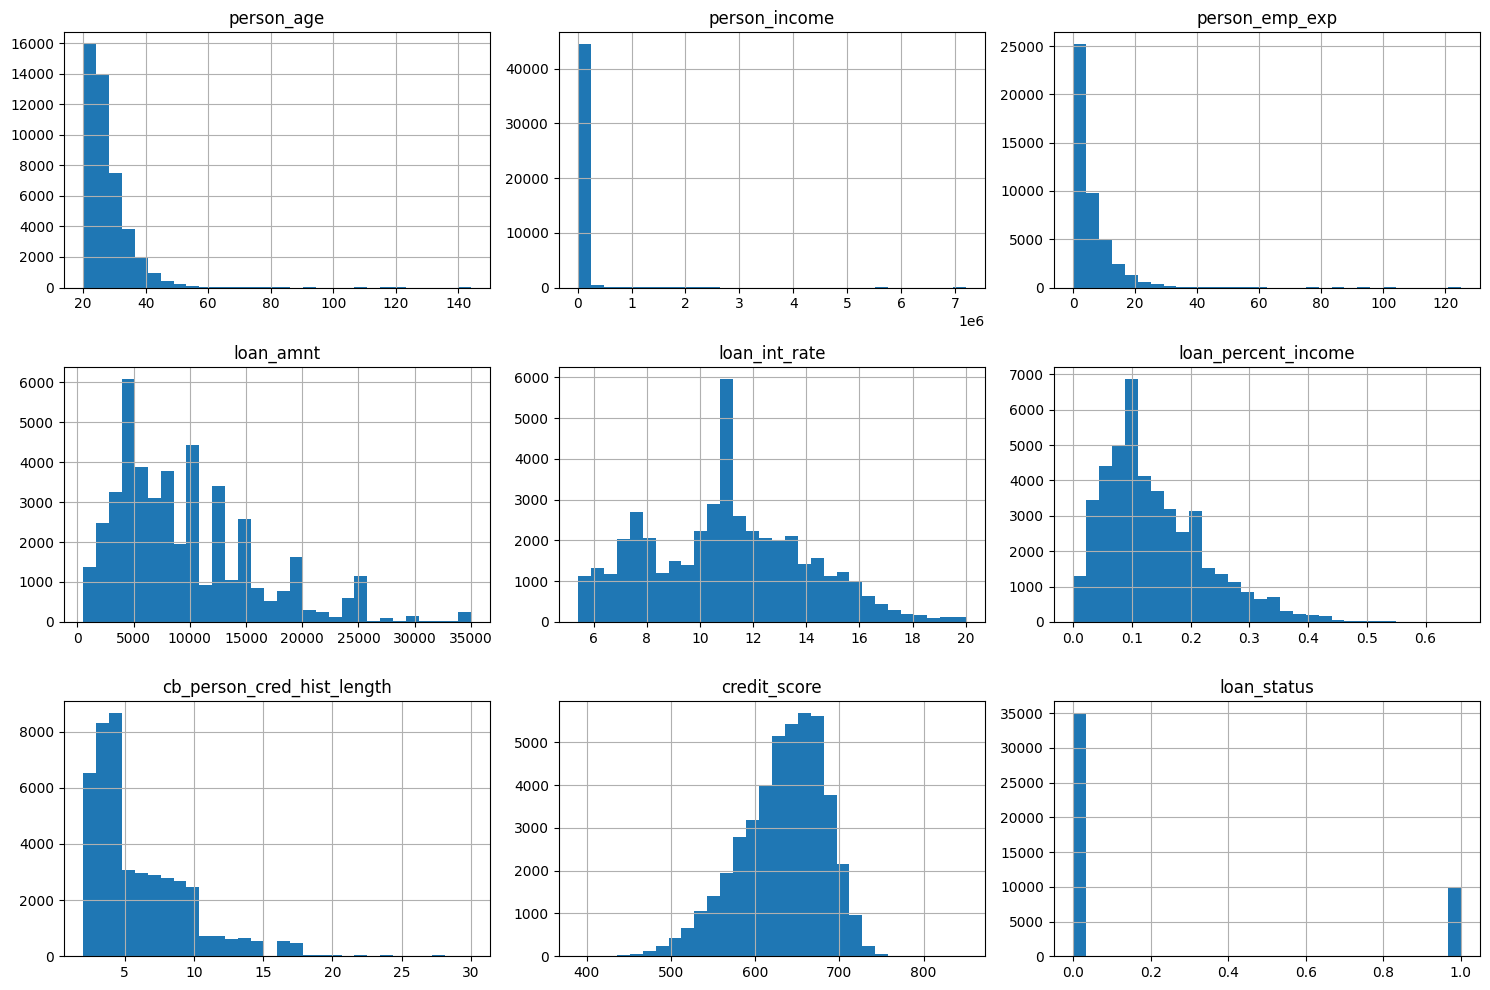

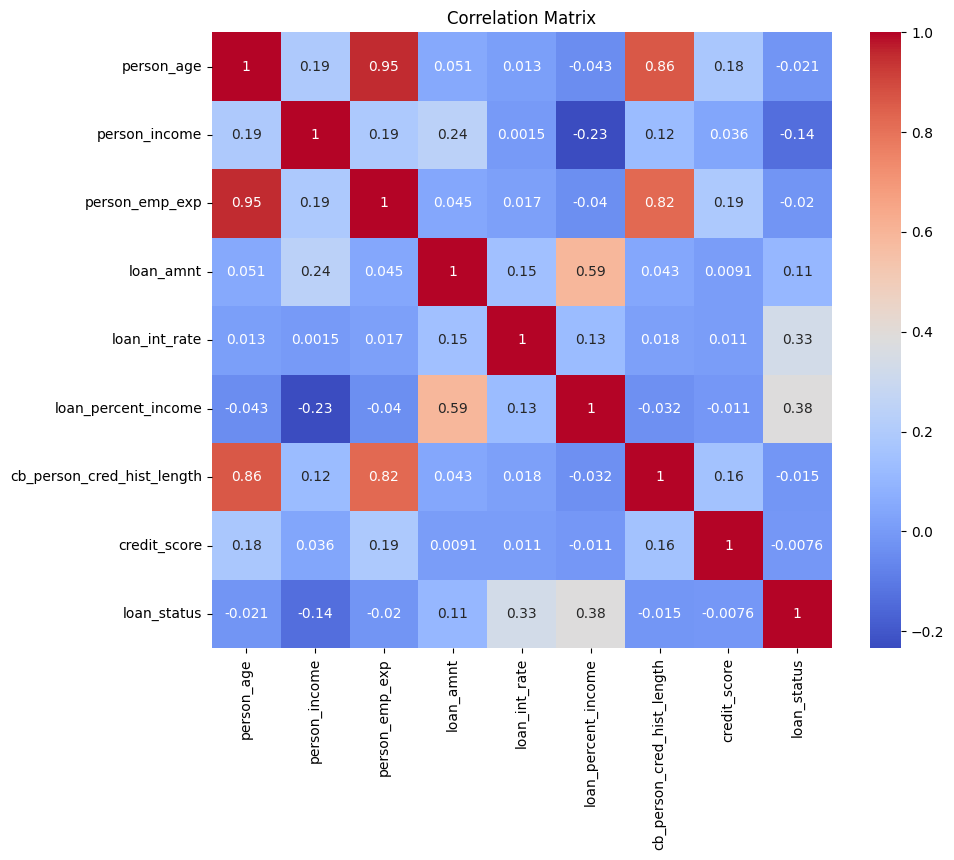

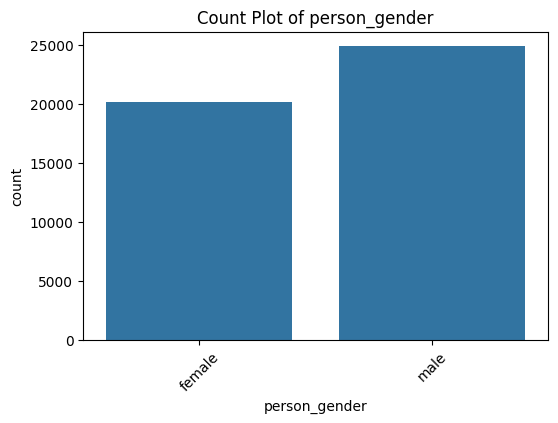

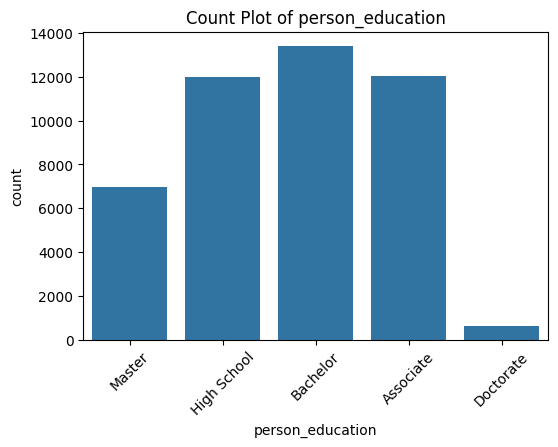

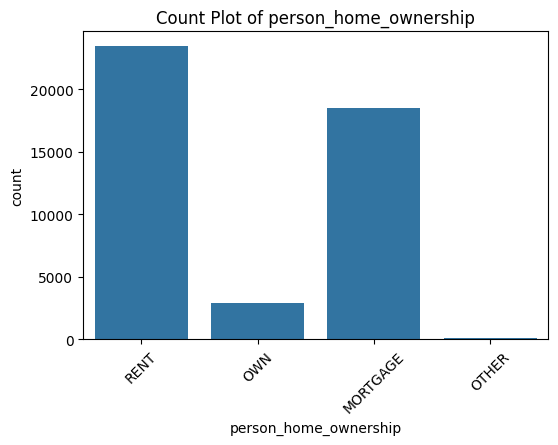

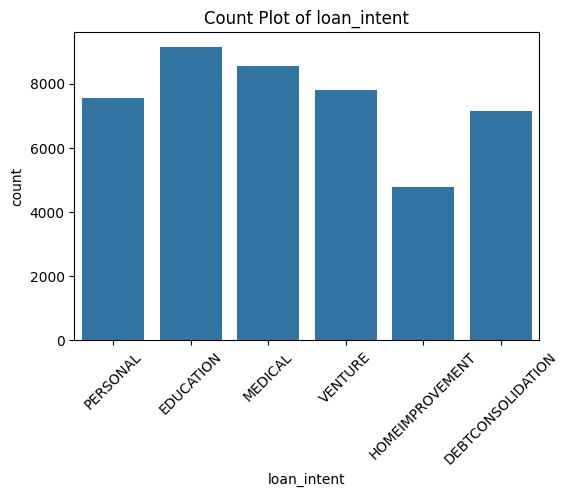

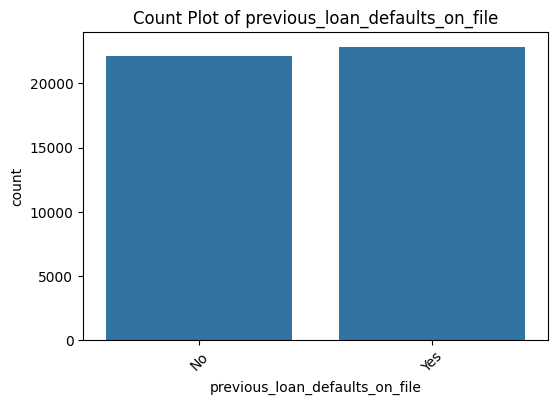

In [ ]:
# Exploratory Data Analysis (EDA) (2)
print("EDA Visualisation through Histograms, Correlation Matrix & Count Plots:")

# Visualize distributions of numerical variables
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols].hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

# Visualize correlations
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Count plots for categorical variables
cat_cols = df.select_dtypes(include=[object]).columns
for col in cat_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=45)
    plt.title(f"Count Plot of {col}")
    plt.show()


In [ ]:
# Detect outliers using IQR
def detect_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[col] < lower_bound) | (data[col] > upper_bound)]

# Identify outliers in numeric columns
for col in num_cols:
    outliers = detect_outliers_iqr(df, col)
    print(f"{col}: {len(outliers)} outliers")

# Drop or cap outliers if needed (optional)
# For now, let's keep them

person_age: 2188 outliers
person_income: 2218 outliers
person_emp_exp: 1724 outliers
loan_amnt: 2348 outliers
loan_int_rate: 124 outliers
loan_percent_income: 744 outliers
cb_person_cred_hist_length: 1366 outliers
credit_score: 467 outliers
loan_status: 10000 outliers


In [ ]:
# Cleaning & Transforming data using One-hot Encoding, Rearranging Columns, Feature Scaling and Feature Selection
# Convert binary categorical values to numeric
df['previous_loan_defaults_on_file'] = df['previous_loan_defaults_on_file'].map({'Yes': 1, 'No': 0})


# One-Hot Encoding for Categorical Columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()  # Identify all categorical columns

# Apply one-hot encoding (drop_first=True avoids dummy variable trap)
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)


# Rearranging Columns (Move the target variable 'loan_status' to the last column)
loan_status = df_encoded.pop('loan_status')   # Remove target temporarily
df_encoded['loan_status'] = loan_status       # Add it back at the end


# Feature Scaling
# Separate features and target again
X = df_encoded.drop('loan_status', axis=1)
y = df_encoded['loan_status']

# Apply StandardScaler to numeric features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)


# Feature Selection using Correlation Filter
# Temporarily add target back to compute correlation
X_scaled['loan_status'] = y

# Compute correlation of each feature with the target
correlations = X_scaled.corr()['loan_status'].drop('loan_status')

# Select features with absolute correlation > 0.05
selected_features = correlations[abs(correlations) > 0.05].index.tolist()

# Final feature set
X_final = X_scaled[selected_features].copy()
y_final = y.copy()

# Output the selected features
print("Selected Features (correlation > 0.05):")
print(selected_features)


Selected Features (correlation > 0.05):
['person_income', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_MEDICAL', 'loan_intent_VENTURE']


In [ ]:
# Split the processed data into training and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=42)


In [ ]:
# Logistic Regression
# Initialize and fit the model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_log = log_model.predict(X_test)

print("🔹 Logistic Regression Results:")
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))
print("Accuracy:", accuracy_score(y_test, y_pred_log))


🔹 Logistic Regression Results:
[[6610  380]
 [1047  963]]
              precision    recall  f1-score   support

           0       0.86      0.95      0.90      6990
           1       0.72      0.48      0.57      2010

    accuracy                           0.84      9000
   macro avg       0.79      0.71      0.74      9000
weighted avg       0.83      0.84      0.83      9000

Accuracy: 0.8414444444444444


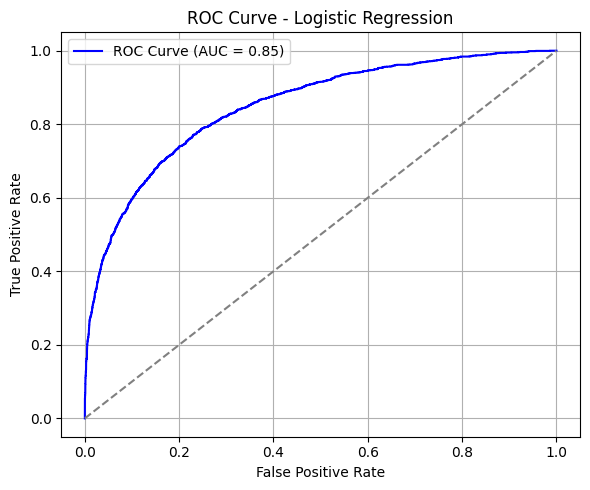

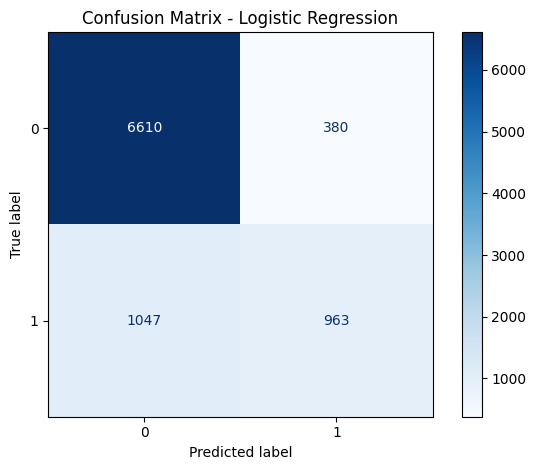

In [ ]:
# Visualise Logistic Regression
from sklearn.metrics import roc_curve, auc, ConfusionMatrixDisplay

# Get prediction probabilities
y_prob_log = log_model.predict_proba(X_test)[:, 1]

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob_log)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})", color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Confusion matrix
ConfusionMatrixDisplay.from_estimator(log_model, X_test, y_test, cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.show()


In [ ]:
# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("🔹 Decision Tree Results:")
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))
print("Accuracy:", accuracy_score(y_test, y_pred_dt))


🔹 Decision Tree Results:
[[6344  646]
 [ 571 1439]]
              precision    recall  f1-score   support

           0       0.92      0.91      0.91      6990
           1       0.69      0.72      0.70      2010

    accuracy                           0.86      9000
   macro avg       0.80      0.81      0.81      9000
weighted avg       0.87      0.86      0.87      9000

Accuracy: 0.8647777777777778


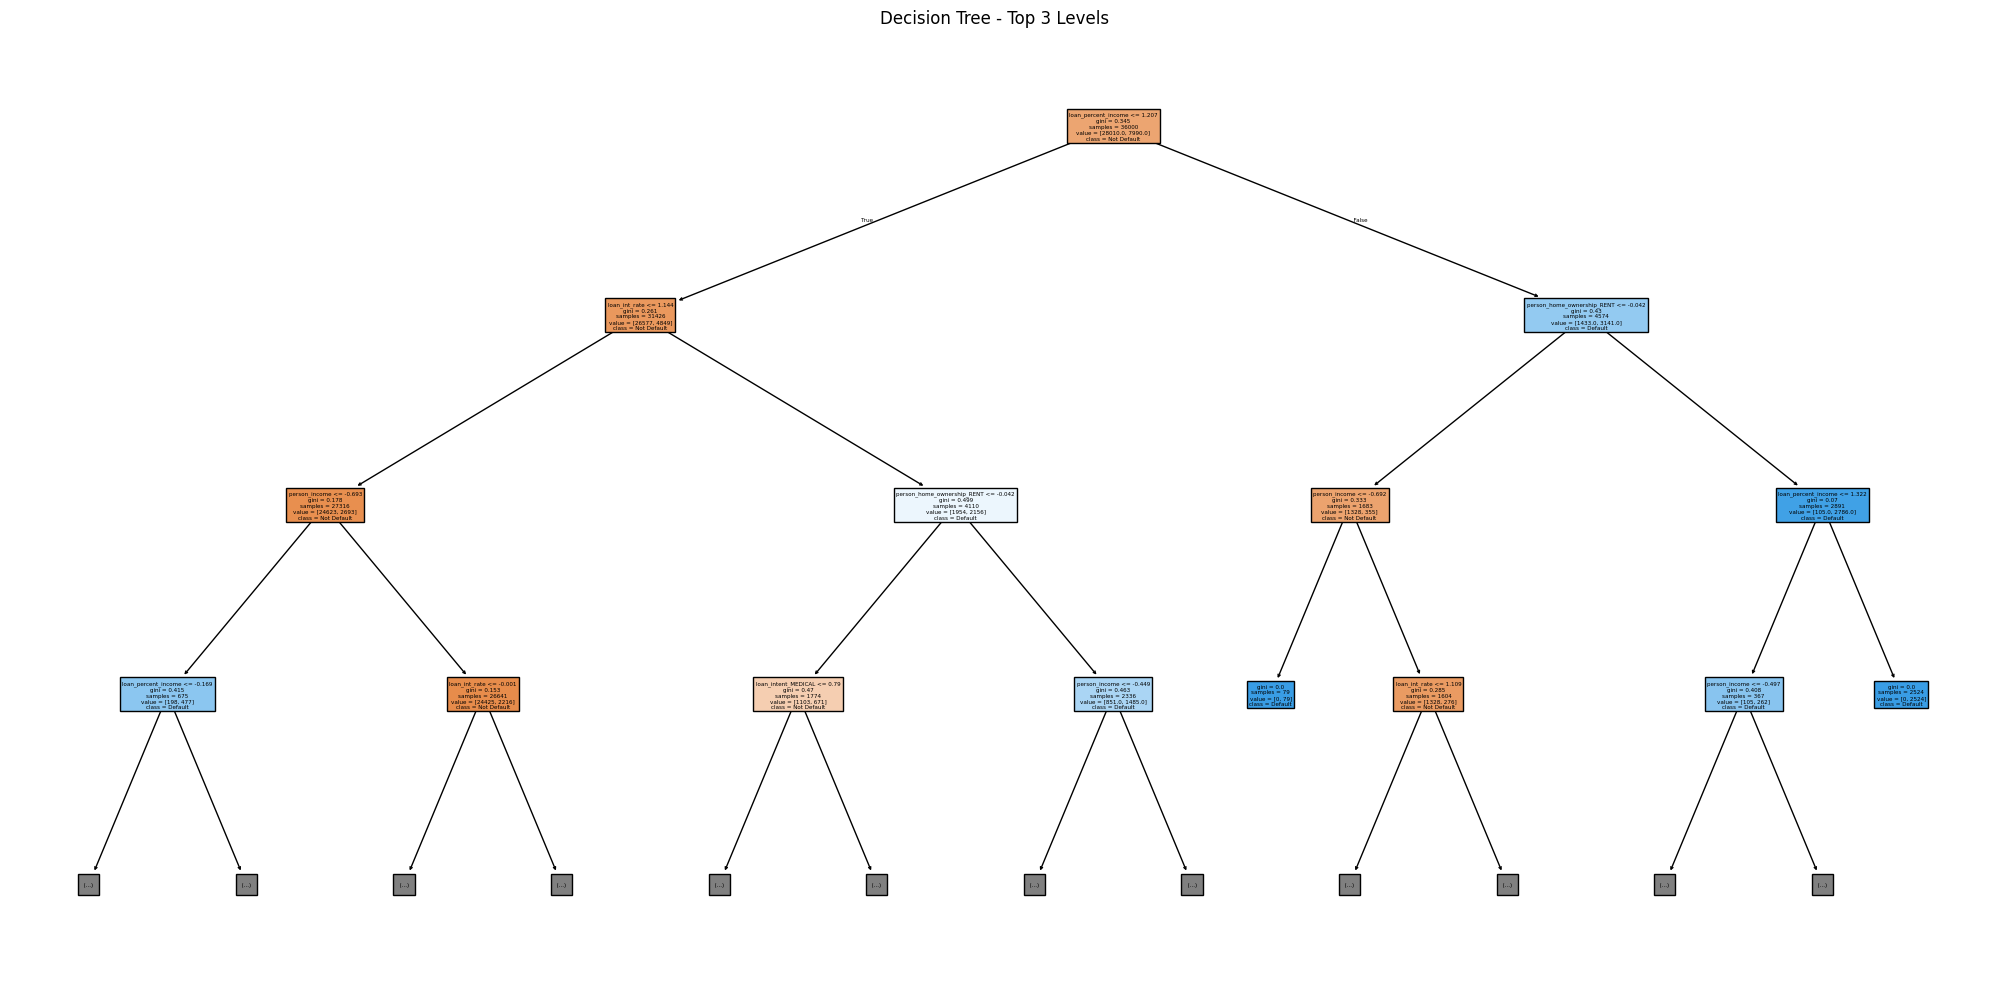

In [ ]:
# Visualise Decision Tree
from sklearn.tree import plot_tree

# Tree visualization
plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=X_train.columns, class_names=["Not Default", "Default"], filled=True, max_depth=3)
plt.title("Decision Tree - Top 3 Levels")
plt.tight_layout()
plt.show()


In [ ]:
# Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("🔹 Random Forest Results:")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))


🔹 Random Forest Results:
[[6786  204]
 [ 659 1351]]
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      6990
           1       0.87      0.67      0.76      2010

    accuracy                           0.90      9000
   macro avg       0.89      0.82      0.85      9000
weighted avg       0.90      0.90      0.90      9000

Accuracy: 0.9041111111111111


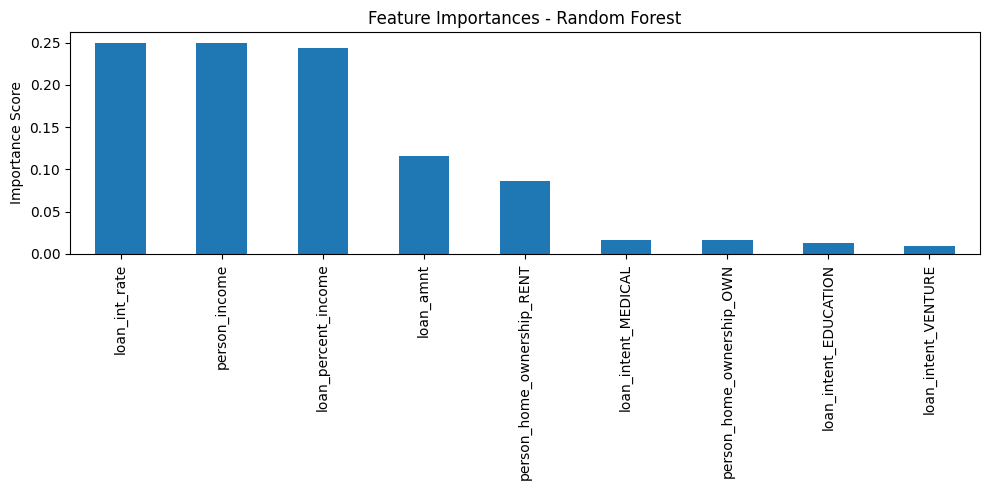

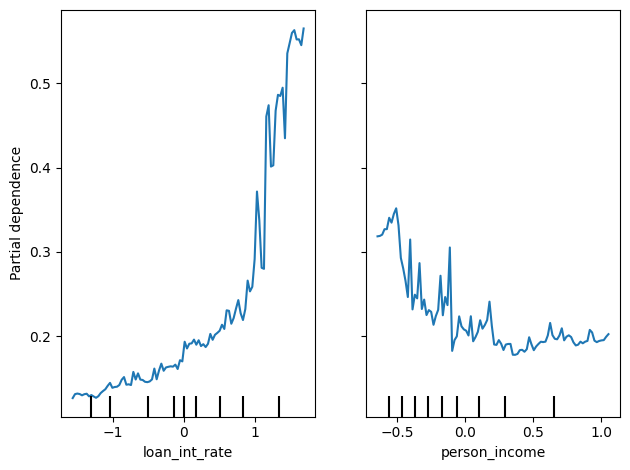

In [ ]:
# Visualise Random Forest
from sklearn.inspection import PartialDependenceDisplay

# Feature importance
rf_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
rf_importances.plot(kind="bar")
plt.title("Feature Importances - Random Forest")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

# Partial Dependence Plot (for top 2 features)
top2_features = rf_importances.index[:2].tolist()
PartialDependenceDisplay.from_estimator(rf_model, X_test, features=top2_features)
plt.tight_layout()
plt.show()


In [ ]:
# Adaboost Classifier
ada_model = AdaBoostClassifier(random_state=42)
ada_model.fit(X_train, y_train)

y_pred_ada = ada_model.predict(X_test)

print("🔹 AdaBoost Classifier Results:")
print(confusion_matrix(y_test, y_pred_ada))
print(classification_report(y_test, y_pred_ada))
print("Accuracy:", accuracy_score(y_test, y_pred_ada))


🔹 AdaBoost Classifier Results:
[[6599  391]
 [ 770 1240]]
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      6990
           1       0.76      0.62      0.68      2010

    accuracy                           0.87      9000
   macro avg       0.83      0.78      0.80      9000
weighted avg       0.87      0.87      0.87      9000

Accuracy: 0.871


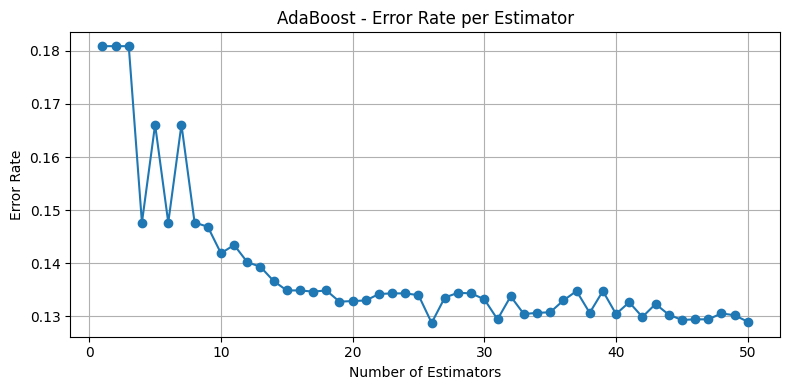

In [ ]:
# Error rates per estimator (available via staged_predict)
errors = []
for y_pred in ada_model.staged_predict(X_test):
    errors.append(1 - accuracy_score(y_test, y_pred))

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(errors) + 1), errors, marker='o')
plt.title("AdaBoost - Error Rate per Estimator")
plt.xlabel("Number of Estimators")
plt.ylabel("Error Rate")
plt.grid(True)
plt.tight_layout()
plt.show()
